In [87]:
import pandas as pd

Reading csv file 

In [88]:
df=pd.read_csv('D:\\Database\\Project\\data.csv')
print(df.head())


  warehouse   product    supplier  stock_level  reorder_level last_updated  \
0      WH-D    Router  Supplier-Y        738.0            432   2025-12-22   
1      WH-B   Printer  Supplier-Z        591.0            313   2025-09-23   
2      WH-E    Router  Supplier-Z        602.0            146   2024-10-14   
3      WH-E    Laptop  Supplier-V        777.0            356   2026-01-03   
4      WH-D  Keyboard  Supplier-X        187.0            431   2025-10-25   

   transport_cost  
0         2194.00  
1         1813.09  
2         2005.75  
3         2395.29  
4         3475.84  


Basic Data Understrading

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   warehouse       1050 non-null   str    
 1   product         1050 non-null   str    
 2   supplier        990 non-null    str    
 3   stock_level     990 non-null    float64
 4   reorder_level   1050 non-null   int64  
 5   last_updated    1050 non-null   str    
 6   transport_cost  990 non-null    float64
dtypes: float64(2), int64(1), str(4)
memory usage: 57.6 KB


In [90]:
df.describe()

,stock_level,reorder_level,transport_cost
count,990.000000,1050.000000,990.000000
mean,486.763636,250.653333,2997.676505
std,290.532990,146.756765,1295.203186
min,0.000000,0.000000,539.250000
25%,237.000000,120.250000,1933.095000
50%,488.000000,250.000000,3049.130000
75%,748.500000,381.000000,4158.965000
max,995.000000,500.000000,5359.820000


In [91]:
df.shape

(1050, 7)

Handling missing and duplicates values

In [92]:
df.isnull().sum()

warehouse          0
product            0
supplier          60
stock_level       60
reorder_level      0
last_updated       0
transport_cost    60
dtype: int64

In [93]:
df['stock_level']=df['stock_level'].fillna(df['stock_level'].mean())
df['transport_cost']=df['transport_cost'].fillna(df['transport_cost'].mean())
df['supplier']=df['supplier'].fillna(df['supplier'].mode()[0])

In [94]:
df=df.drop_duplicates()

In [95]:
df.shape

(1000, 7)

EDA

In [96]:
!pip install matplotlib seaborn

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

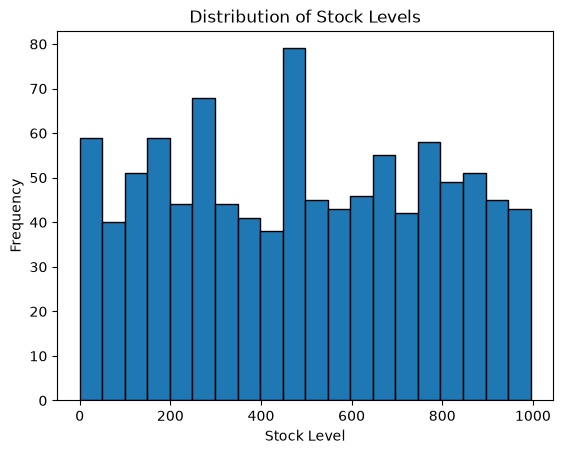

In [98]:

plt.hist(df['stock_level'],bins=20,edgecolor='black')
plt.xlabel('Stock Level')
plt.ylabel('Frequency')
plt.title('Distribution of Stock Levels')
plt.show()

Categorical encoding

In [99]:
warehouse_dummies=pd.get_dummies(df['warehouse'],prefix='warehouse',drop_first=True)
supplier_dummies=pd.get_dummies(df['supplier'],prefix='supplier',drop_first=True)
product_dummies=pd.get_dummies(df['product'],prefix='product',drop_first=True)

In [100]:
df = pd.concat(
    [df, warehouse_dummies, supplier_dummies, product_dummies],
    axis=1
)

df.drop(['warehouse', 'supplier', 'product'], axis=1, inplace=True)

Feature engineering

Transport Cost 

In [101]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['weekday'] = df['last_updated'].dt.weekday


In [102]:
df.drop('last_updated', axis=1, inplace=True)

In [103]:
X=df.drop(['transport_cost'],axis=1)
y=df['transport_cost']

Splitting data

In [105]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [106]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

ML MODELS

Regression

In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print(f"mean square error {mean_squared_error(y_test,y_pred)}")
print(f"mean absolute error {mean_absolute_error(y_test,y_pred)}")
print(f"r2 score{r2_score(y_test,y_pred)}")


mean square error 1515129.1726185603
mean absolute error 1021.945579430231
r2 score-0.04025444752915108


Classification

In [108]:
df['stock_shortage_risk']=(df['stock_level']<df['reorder_level']).astype(int)

In [109]:
X=df.drop(['transport_cost','stock_shortage_risk'],axis=1)
y=df['stock_shortage_risk']

In [111]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [112]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

In [115]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

print(f"accuracy {accuracy_score(y_test,y_pred)}")
print(f"precision {precision_score(y_test,y_pred)}")
print(f"recall {recall_score(y_test,y_pred)}")
print(f"f1 {f1_score(y_test,y_pred)}")
print(f"roc_auc {roc_auc_score(y_test,y_pred)}")

accuracy 1.0
precision 1.0
recall 1.0
f1 1.0
roc_auc 1.0
